Data root : C:\Users\miy\Downloads\1000_논문투고\68.독거노인 돌봄용 위험감지 데이터\3.개방데이터\1.데이터
Fig  dir  : C:\Users\miy\Downloads\1000_논문투고\68.독거노인 돌봄용 위험감지 데이터\3.개방데이터\causal_fusion_paper\figures
Results   : C:\Users\miy\Downloads\1000_논문투고\68.독거노인 돌봄용 위험감지 데이터\3.개방데이터\causal_fusion_paper\results
Loaded : (109819, 29)   Households : 27

HH_ID     n_segments  total_steps  largest_seg
-----------------------------------------------
  A0002            11        4,544        1,130
  A0003             9        6,161        2,437
  A0004             9        5,783        1,940
  A0005             8        3,233          874
  A0006             0            0            0
  A0007             6        2,429          764
  A0008             8        4,658        1,427
  A0009             0            0            0
  A0010             9        5,901        1,958
  A0012             8        3,724          675
  A0013            10        5,127        2,304
  A0014             5        2,414        1,039
  A0

,Source,Target,Lag,Lag_min,Val_corr,P_value
0,Activity_IR,Activity_IR,1,10,0.4282,0.0000
3,HeartRate,Activity_IR,1,10,0.0426,0.0000
9,StressIndex,Activity_IR,1,10,0.0229,0.0211
15,Humidity,Activity_IR,1,10,0.0336,0.0405
20,CO2,Activity_IR,1,10,-0.0598,0.0000
...,...,...,...,...,...,...
129,Risk_bin,Temperature,5,50,0.0016,0.0150
111,BreathRate,Temperature,6,60,0.0144,0.0209
118,Temperature,Temperature,6,60,-0.0106,0.0132
125,CO2,Temperature,6,60,0.0184,0.0460


Saved → results/causal_links_A0030.csv
Saved → C:\Users\miy\Downloads\1000_논문투고\68.독거노인 돌봄용 위험감지 데이터\3.개방데이터\causal_fusion_paper\figures\fig_causal_dag_A0030.png


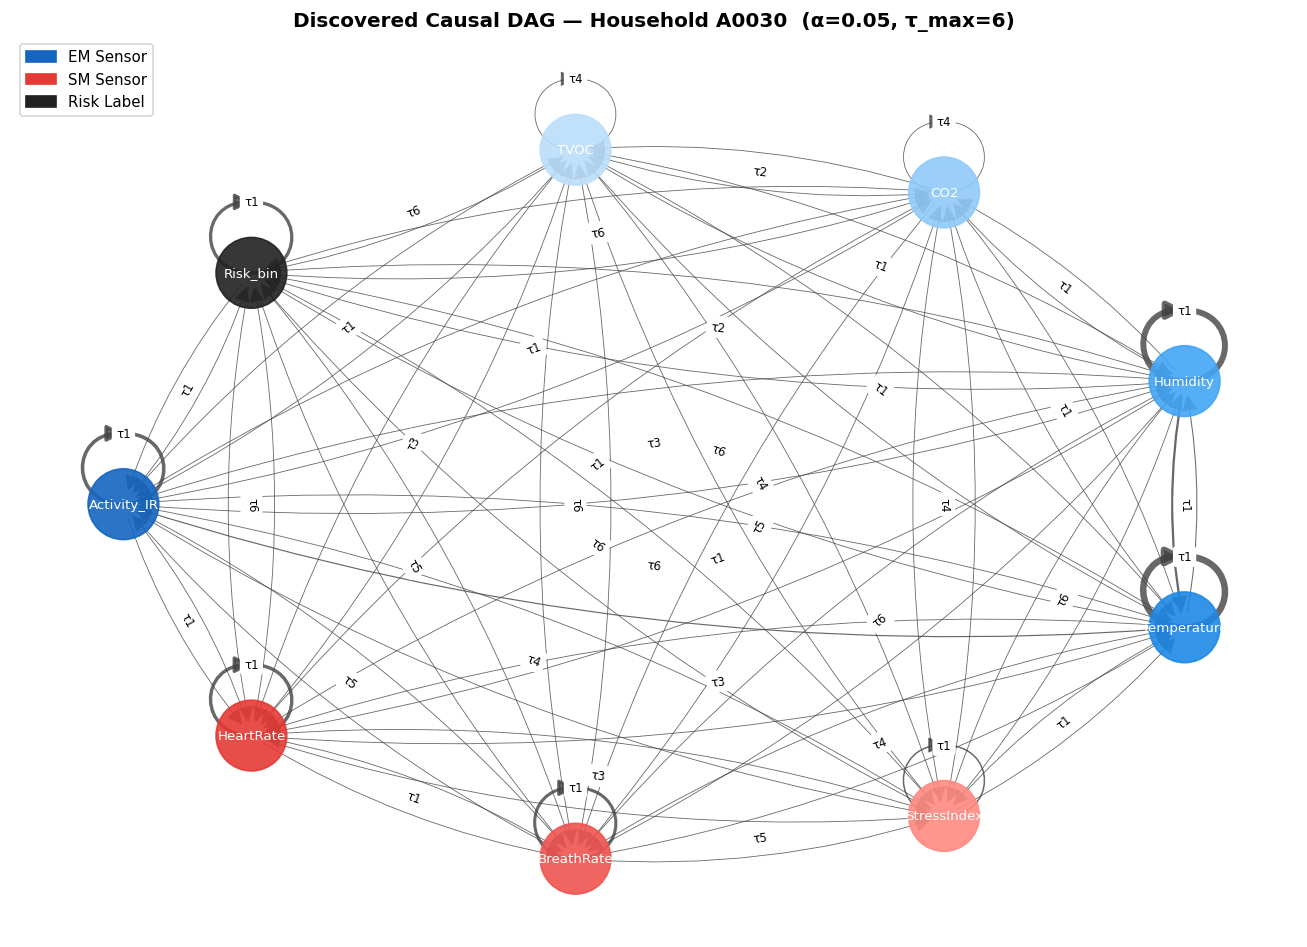


Batch PCMCI — 24 households

  ✅ A0002  links: 257
  ✅ A0003  links: 241
  ✅ A0004  links: 265
  ✅ A0005  links: 248
  ✅ A0007  links: 187
  ✅ A0008  links: 213
  ✅ A0010  links: 233
  ✅ A0012  links: 258
  ✅ A0013  links: 264
  ✅ A0014  links: 177
  ✅ A0015  links: 339
  ✅ A0016  links: 229
  ✅ A0017  links: 148
  ✅ A0018  links: 293
  ✅ A0019  links: 128
  ✅ A0022  links: 245
  ✅ A0023  links: 205
  ✅ A0024  links: 323
  ✅ A0025  links: 283
  ✅ A0026  links: 272
  ✅ A0027  links: 120
  ✅ A0028  links: 291
  ✅ A0029  links: 186
  ✅ A0030  links: 211

Total significant links : 5616
Failed households       : []
Saved → results/causal_links_all.csv

Stable causal links (freq ≥ 50%):


,Source,Target,Lag,n_hh,mean_val,freq
481,Temperature,Temperature,2,24,-0.2081,1.0
0,Activity_IR,Activity_IR,1,24,0.3487,1.0
180,HeartRate,HeartRate,1,24,0.4222,1.0
360,StressIndex,StressIndex,1,24,0.1957,1.0
264,Humidity,Temperature,1,24,0.1428,1.0
...,...,...,...,...,...,...
232,Humidity,CO2,5,12,0.0002,0.5
179,HeartRate,CO2,6,12,0.0017,0.5
229,Humidity,CO2,2,12,-0.0142,0.5
484,Temperature,Temperature,5,12,0.0005,0.5


Saved → results/stable_causal_links.csv


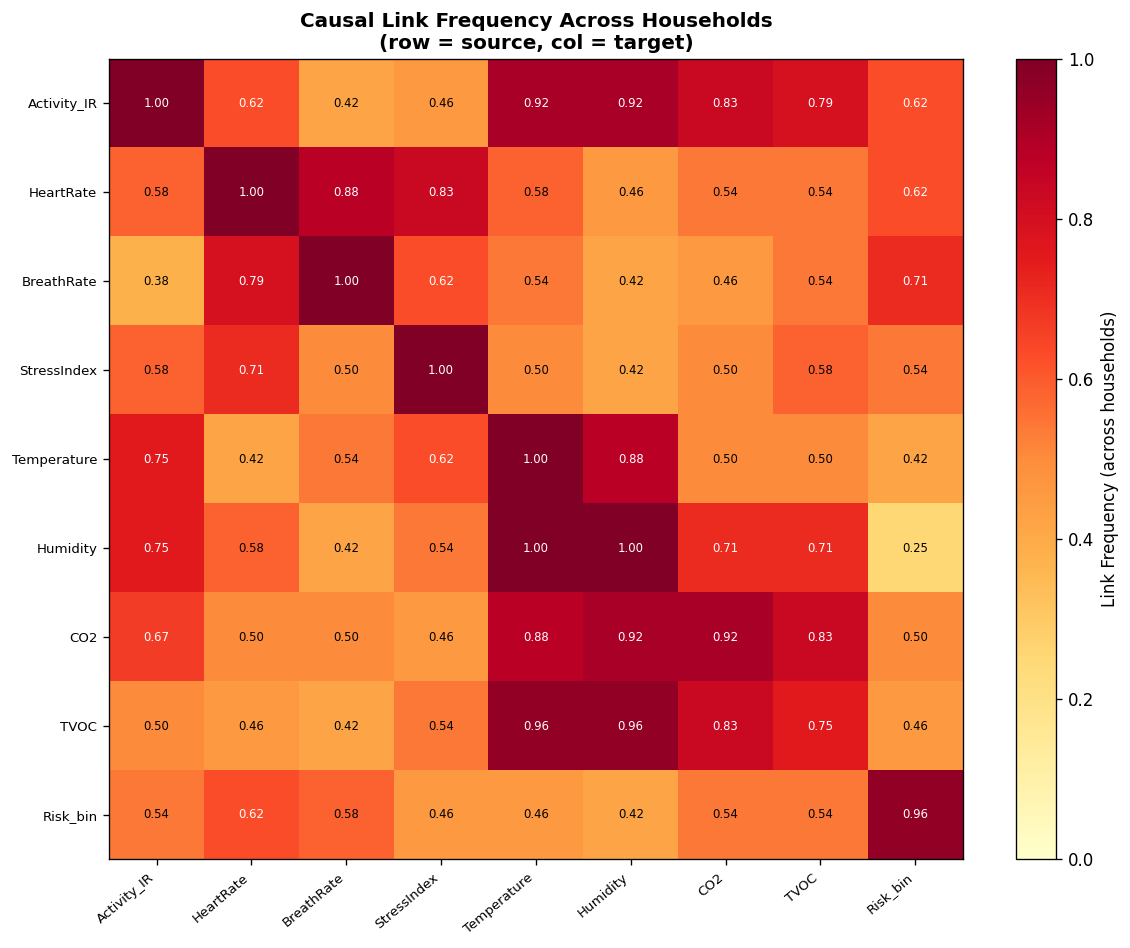

Saved → figures/fig_causal_freq_heatmap.png
Saved → C:\Users\miy\Downloads\1000_논문투고\68.독거노인 돌봄용 위험감지 데이터\3.개방데이터\causal_fusion_paper\figures\fig_causal_dag_aggregate.png


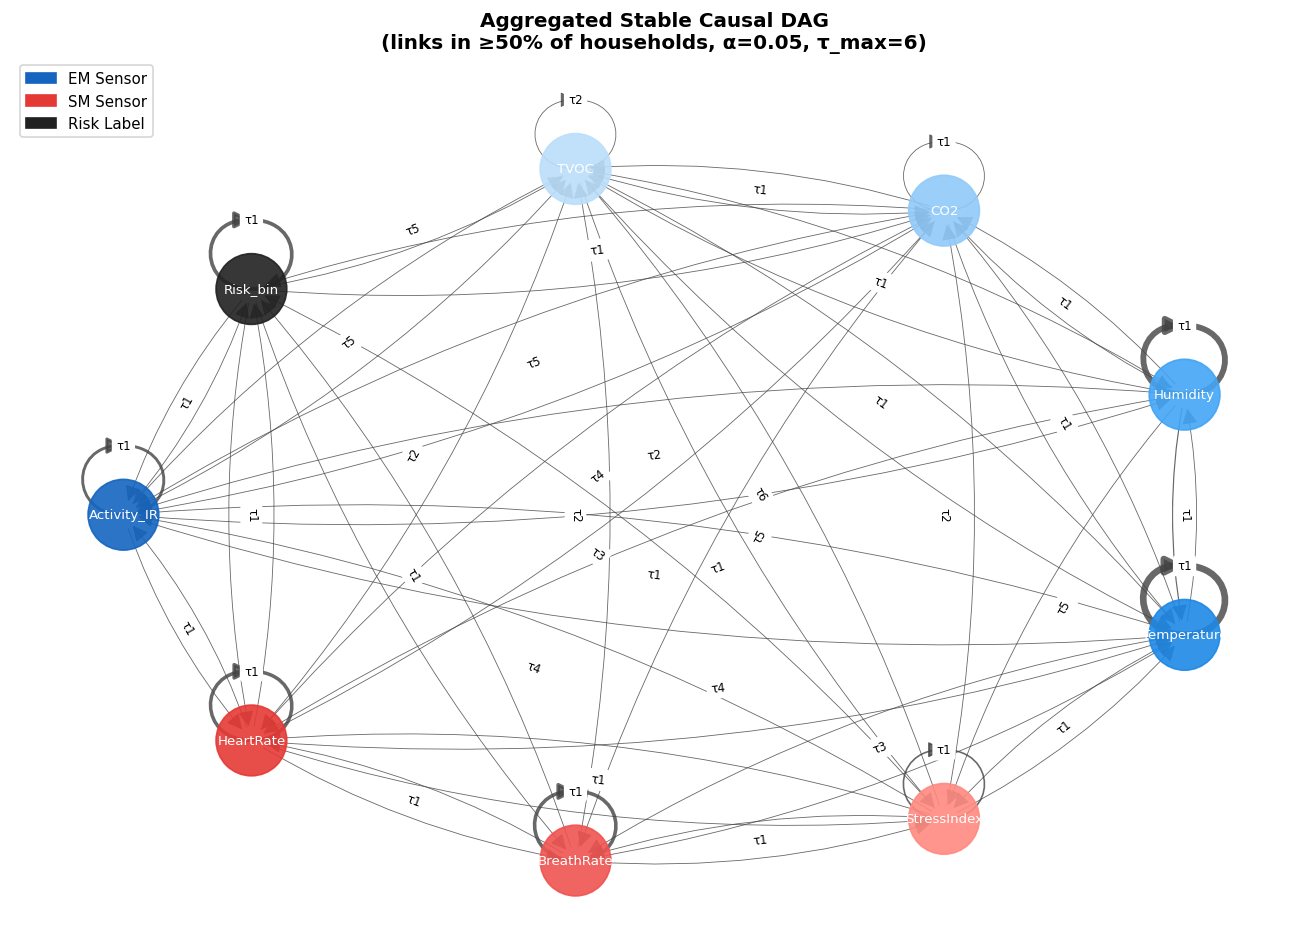

Adjacency matrix saved → results/causal_adj.npy
Shape : (9, 9, 7)  (N_sensors × N_sensors × tau_max+1)
Non-zero entries : 209

Stable causal edges (GNN initialisation):
  Activity_IR(t-1) → Activity_IR(t)
  Activity_IR(t-2) → Activity_IR(t)
  Activity_IR(t-3) → Activity_IR(t)
  Activity_IR(t-4) → Activity_IR(t)
  Activity_IR(t-5) → Activity_IR(t)
  Activity_IR(t-1) → HeartRate(t)
  Activity_IR(t-2) → HeartRate(t)
  Activity_IR(t-5) → HeartRate(t)
  Activity_IR(t-6) → HeartRate(t)
  Activity_IR(t-1) → Temperature(t)
  Activity_IR(t-2) → Temperature(t)
  Activity_IR(t-3) → Temperature(t)
  Activity_IR(t-4) → Temperature(t)
  Activity_IR(t-5) → Temperature(t)
  Activity_IR(t-1) → Humidity(t)
  Activity_IR(t-2) → Humidity(t)
  Activity_IR(t-3) → Humidity(t)
  Activity_IR(t-4) → Humidity(t)
  Activity_IR(t-5) → Humidity(t)
  Activity_IR(t-6) → Humidity(t)
  Activity_IR(t-1) → CO2(t)
  Activity_IR(t-2) → CO2(t)
  Activity_IR(t-3) → CO2(t)
  Activity_IR(t-4) → CO2(t)
  Activity_IR(t-1) → TVOC

In [4]:
# ============================================================
# Notebook : 02_pcmci.ipynb
# Path     : causal_fusion_paper/02_pcmci.ipynb
# Purpose  : Temporal Causal Discovery via PCMCI+
#            for Elderly Risk Detection Multimodal Sensor Data
# Author   : [Your Name]
# Created  : 2026-06-11
# ============================================================


# ── Cell 0. Imports & Paths ──────────────────────────────────
import json, warnings
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.unicode_minus': False,
    'figure.dpi':        120,
    'font.size':         10,
})

ROOT    = Path().resolve()                  # causal_fusion_paper/
DATA    = Path((ROOT / "DATA_PATH.txt").read_text().strip())
FIG_DIR = ROOT / "figures"
RES_DIR = ROOT / "results"
CACHE   = ROOT / "data_cache"

print(f"Data root : {DATA}")
print(f"Fig  dir  : {FIG_DIR}")
print(f"Results   : {RES_DIR}")


# ── Cell 1. Load Cached Data ─────────────────────────────────
df = pd.read_pickle(CACHE / "df_new.pkl")

df['Estimation_EN'] = df['Estimation'].map({
    '위험': 'Danger',       '주의': 'Caution',
    '수면': 'Normal-sleep', '식사': 'Normal-meal',
    '외출': 'Normal-out',   '기타': 'Normal-other',
})
df['Risk_bin'] = df['Estimation'].isin(['위험', '주의']).astype(float)
df.loc[df['Estimation'].isna(), 'Risk_bin'] = np.nan
df.sort_values(['HH_ID', 'Timestamp'], inplace=True)

# Sensor columns used in PCMCI
# Risk_bin included so we can discover which sensors causally precede risk
SENSOR_COLS = [
    'Activity_IR', 'HeartRate', 'BreathRate',
    'StressIndex', 'Temperature', 'Humidity',
    'CO2', 'TVOC', 'Risk_bin',
]
print(f"Loaded : {df.shape}   Households : {df['HH_ID'].nunique()}")


# ── Cell 2. Gap-Aware Segment Extractor ──────────────────────
# PCMCI requires strictly equally-spaced, gap-free time series.
# Strategy: split each household's timeline at gaps > 15 min,
#           keep only segments long enough for reliable inference.

MIN_SEG_LEN = 100    # minimum timesteps per segment (= 1000 min ≈ 16.7 h)
GAP_THRESH  = 15     # minutes — gap threshold

def extract_segments(hh_df: pd.DataFrame,
                     cols: list,
                     min_len: int = MIN_SEG_LEN,
                     gap_thresh: int = GAP_THRESH) -> list[np.ndarray]:
    """
    Split a household DataFrame into gap-free segments.
    Returns a list of 2-D numpy arrays (T × N_sensors).
    """
    hh_df  = hh_df.sort_values('Timestamp').copy()
    diff   = hh_df['Timestamp'].diff().dt.total_seconds().div(60)
    breaks = hh_df.index[diff > gap_thresh].tolist()

    segments, start = [], hh_df.index[0]
    for brk in breaks + [None]:
        seg = hh_df.loc[start: hh_df.index[hh_df.index.get_loc(brk) - 1]
                        if brk else hh_df.index[-1], cols]
        arr = seg.apply(pd.to_numeric, errors='coerce').values
        if len(arr) >= min_len and not np.all(np.isnan(arr)):
            segments.append(arr)
        start = brk
    return segments


# Preview segment counts per household
print(f"\n{'HH_ID':<8} {'n_segments':>11} {'total_steps':>12} {'largest_seg':>12}")
print("-" * 47)
seg_summary = []
for hh, grp in df.groupby('HH_ID'):
    segs = extract_segments(grp, SENSOR_COLS)
    total = sum(len(s) for s in segs)
    largest = max((len(s) for s in segs), default=0)
    seg_summary.append({'HH_ID': hh, 'n_seg': len(segs),
                        'total': total, 'largest': largest})
    print(f"  {hh:<8} {len(segs):>10} {total:>12,} {largest:>12,}")

df_seg = pd.DataFrame(seg_summary)

# Households with at least 1 usable segment
usable = df_seg[df_seg['n_seg'] > 0]['HH_ID'].tolist()
print(f"\nUsable households : {len(usable)} / {df['HH_ID'].nunique()}")


# ── Cell 3. Single-Household PCMCI (sanity check) ───────────
# Run PCMCI on the household with the most Danger events (A0030)
# to verify the pipeline before batch processing.

TARGET_HH = 'A0030'
TAU_MAX   = 6        # maximum lag to test (6 × 10 min = 60 min)
ALPHA     = 0.05     # significance threshold

print(f"\n{'='*60}")
print(f"PCMCI Sanity Check — Household {TARGET_HH}")
print(f"  tau_max = {TAU_MAX} lags  |  alpha = {ALPHA}")
print(f"{'='*60}")

hh_df   = df[df['HH_ID'] == TARGET_HH]
segs    = extract_segments(hh_df, SENSOR_COLS)
print(f"  Segments : {len(segs)}   "
      f"Lengths : {[len(s) for s in segs]}")

# Concatenate all segments with NaN separators (tigramite handles this)
def concat_with_nan(segs: list[np.ndarray], n_cols: int) -> np.ndarray:
    nan_row = np.full((1, n_cols), np.nan)
    parts   = []
    for s in segs:
        parts.append(s)
        parts.append(nan_row)
    return np.vstack(parts[:-1])   # drop trailing NaN row

data_arr = concat_with_nan(segs, len(SENSOR_COLS))

# Run PCMCI on each segment separately, then aggregate p-values
# via Fisher's method (minimum p across segments per link)
def run_pcmci_on_segments(segs, var_names, tau_max=TAU_MAX, alpha=ALPHA):
    """
    Run PCMCI independently on each gap-free segment.
    Aggregate results: keep minimum p-value across segments per link.
    Returns aggregated results dict with p_matrix and val_matrix.
    """
    N          = len(var_names)
    p_agg      = np.ones( (N, N, tau_max + 1))   # init p=1
    v_agg      = np.zeros((N, N, tau_max + 1))
    seg_counts = 0

    for seg in segs:
        # Drop rows with any NaN
        seg_clean = seg[~np.isnan(seg).any(axis=1)]
        if len(seg_clean) < 30:   # too short after NaN drop
            continue
        try:
            df_seg = pp.DataFrame(seg_clean, var_names=var_names)
            pc     = PCMCI(dataframe=df_seg,
                           cond_ind_test=ParCorr(significance='analytic'),
                           verbosity=0)
            res    = pc.run_pcmci(tau_min=1, tau_max=tau_max,
                                  alpha_level=alpha)
            # Keep minimum p-value (most significant) across segments
            p_agg = np.minimum(p_agg, res['p_matrix'])
            # Weighted accumulate val_matrix by segment length
            v_agg += res['val_matrix'] * len(seg_clean)
            seg_counts += len(seg_clean)
        except Exception:
            continue

    if seg_counts > 0:
        v_agg /= seg_counts
    return {'p_matrix': p_agg, 'val_matrix': v_agg}

results = run_pcmci_on_segments(segs, SENSOR_COLS)
print(f"\n  PCMCI completed.")
print(f"  p-value matrix shape : {results['p_matrix'].shape}")


# ── Cell 4. Extract & Display Significant Causal Links ───────
def get_significant_links(results, var_names, alpha=ALPHA):
    """Return DataFrame of significant causal links."""
    p_mat  = results['p_matrix']   # shape (N, N, tau_max+1)
    mv_mat = results['val_matrix']
    N      = len(var_names)
    rows   = []
    for j in range(N):             # target
        for i in range(N):         # source
            for tau in range(1, p_mat.shape[2]):
                p = p_mat[i, j, tau]
                v = mv_mat[i, j, tau]
                if p < alpha:
                    rows.append({
                        'Source':    var_names[i],
                        'Target':    var_names[j],
                        'Lag':       tau,
                        'Lag_min':   tau * 10,
                        'Val_corr':  round(v, 4),
                        'P_value':   round(p, 4),
                    })
    return pd.DataFrame(rows).sort_values(['Target', 'Lag'])

links_df = get_significant_links(results, SENSOR_COLS)
print(f"\nSignificant causal links ({TARGET_HH}):")
display(links_df)

# Save
links_df.to_csv(RES_DIR / f"causal_links_{TARGET_HH}.csv", index=False)
print(f"Saved → results/causal_links_{TARGET_HH}.csv")


# ── Cell 5. Visualise Causal Graph (DAG) ─────────────────────
# Draw the discovered causal DAG for the target household.
# Node colour encodes sensor modality; edge width encodes |val_corr|.

MODALITY_COLOR = {
    'Activity_IR':  '#1565C0',   # EM — blue
    'Temperature':  '#1E88E5',
    'Humidity':     '#42A5F5',
    'CO2':          '#90CAF9',
    'TVOC':         '#BBDEFB',
    'HeartRate':    '#E53935',   # SM — red
    'BreathRate':   '#EF5350',
    'StressIndex':  '#FF8A80',
    'Risk_bin':     '#212121',   # label — black
}

def draw_causal_dag(links: pd.DataFrame, var_names: list,
                    title: str = '', save_path=None):
    G = nx.DiGraph()
    G.add_nodes_from(var_names)
    # Support both raw links (Val_corr) and aggregated stable links (mean_val)
    val_col = 'Val_corr' if 'Val_corr' in links.columns else 'mean_val'
    for _, row in links.iterrows():
        key = (row['Source'], row['Target'])
        # keep only the strongest lag per pair
        if G.has_edge(*key):
            if abs(row[val_col]) <= abs(G[row['Source']][row['Target']]['weight']):
                continue
        G.add_edge(row['Source'], row['Target'],
                   weight=row[val_col],
                   lag=row['Lag'])

    pos    = nx.shell_layout(G)
    colors = [MODALITY_COLOR.get(n, '#9E9E9E') for n in G.nodes()]
    widths = [max(0.5, abs(G[u][v]['weight']) * 5) for u, v in G.edges()]
    edge_labels = {(u, v): f"τ{G[u][v]['lag']}" for u, v in G.edges()}

    fig, ax = plt.subplots(figsize=(11, 8))
    nx.draw_networkx_nodes(G, pos, node_color=colors,
                           node_size=1800, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8,
                            font_color='white', ax=ax)
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.8,
                           edge_color='#424242', arrows=True,
                           arrowsize=20,
                           connectionstyle='arc3,rad=0.1', ax=ax)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                 font_size=7, ax=ax)

    legend = [
        mpatches.Patch(color='#1565C0', label='EM Sensor'),
        mpatches.Patch(color='#E53935', label='SM Sensor'),
        mpatches.Patch(color='#212121', label='Risk Label'),
    ]
    ax.legend(handles=legend, loc='upper left', fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()

draw_causal_dag(
    links_df, SENSOR_COLS,
    title=f'Discovered Causal DAG — Household {TARGET_HH}  (α={ALPHA}, τ_max={TAU_MAX})',
    save_path=FIG_DIR / f'fig_causal_dag_{TARGET_HH}.png',
)


# ── Cell 6. Batch PCMCI — All Usable Households ──────────────
# Run PCMCI for every household with ≥1 usable segment.
# Aggregate results into a single link table.

print(f"\n{'='*60}")
print(f"Batch PCMCI — {len(usable)} households")
print(f"{'='*60}\n")

all_links = []
failed    = []

for hh in usable:
    try:
        hh_df = df[df['HH_ID'] == hh]
        segs  = extract_segments(hh_df, SENSOR_COLS)
        if not segs:
            continue

        res       = run_pcmci_on_segments(segs, SENSOR_COLS, TAU_MAX, ALPHA)
        ldf       = get_significant_links(res, SENSOR_COLS, ALPHA)
        ldf['HH_ID'] = hh
        all_links.append(ldf)
        print(f"  ✅ {hh}  links: {len(ldf)}")

    except Exception as e:
        failed.append(hh)
        print(f"  ❌ {hh}  ERROR: {e}")

df_links = pd.concat(all_links, ignore_index=True) if all_links else pd.DataFrame()
df_links.to_csv(RES_DIR / "causal_links_all.csv", index=False)
print(f"\nTotal significant links : {len(df_links)}")
print(f"Failed households       : {failed}")
print(f"Saved → results/causal_links_all.csv")


# ── Cell 7. Aggregate Causal Link Frequency ──────────────────
# Count how many households share each (Source → Target, Lag) triplet.
# Links appearing in ≥50% of households are treated as stable
# and used to initialise the GNN adjacency matrix in 03_causal_gnn.ipynb.

FREQ_THRESH = 0.5   # must appear in ≥ 50% of households

if len(df_links) > 0:
    freq = (df_links.groupby(['Source', 'Target', 'Lag'])
                    .agg(n_hh=('HH_ID', 'nunique'),
                         mean_val=('Val_corr', 'mean'))
                    .reset_index()
                    .assign(freq=lambda x: x['n_hh'] / len(usable))
                    .sort_values('freq', ascending=False))

    stable = freq[freq['freq'] >= FREQ_THRESH].copy()
    print(f"\nStable causal links (freq ≥ {FREQ_THRESH*100:.0f}%):")
    display(stable.round(4))
    stable.to_csv(RES_DIR / "stable_causal_links.csv", index=False)
    print(f"Saved → results/stable_causal_links.csv")

    # ── Figure: link frequency heatmap (Source × Target, best lag)
    best_lag = freq.sort_values('freq', ascending=False).drop_duplicates(['Source','Target'])
    pivot    = best_lag.pivot(index='Source', columns='Target', values='freq').fillna(0)
    pivot    = pivot.reindex(index=SENSOR_COLS, columns=SENSOR_COLS, fill_value=0)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(pivot.values, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, label='Link Frequency (across households)')
    ax.set_xticks(range(len(SENSOR_COLS)))
    ax.set_yticks(range(len(SENSOR_COLS)))
    ax.set_xticklabels(SENSOR_COLS, rotation=40, ha='right', fontsize=8)
    ax.set_yticklabels(SENSOR_COLS, fontsize=8)
    ax.set_title('Causal Link Frequency Across Households\n'
                 '(row = source, col = target)',
                 fontsize=12, fontweight='bold')
    for i in range(len(SENSOR_COLS)):
        for j in range(len(SENSOR_COLS)):
            v = pivot.values[i, j]
            if v > 0:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=7,
                        color='white' if v > 0.6 else 'black')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig_causal_freq_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved → figures/fig_causal_freq_heatmap.png")


# ── Cell 8. Aggregate DAG (stable links only) ────────────────
if len(df_links) > 0 and len(stable) > 0:
    draw_causal_dag(
        stable, SENSOR_COLS,
        title=f'Aggregated Stable Causal DAG\n'
              f'(links in ≥{FREQ_THRESH*100:.0f}% of households, '
              f'α={ALPHA}, τ_max={TAU_MAX})',
        save_path=FIG_DIR / 'fig_causal_dag_aggregate.png',
    )


# ── Cell 9. GNN Adjacency Matrix Export ──────────────────────
# Convert stable links to a binary adjacency matrix (N × N × tau_max).
# This matrix directly initialises the edge structure of the
# Causal-Guided GNN in 03_causal_gnn.ipynb.

N   = len(SENSOR_COLS)
ADJ = np.zeros((N, N, TAU_MAX + 1), dtype=np.float32)

if len(df_links) > 0 and len(stable) > 0:
    idx = {name: i for i, name in enumerate(SENSOR_COLS)}
    for _, row in stable.iterrows():
        i = idx[row['Source']]
        j = idx[row['Target']]
        t = int(row['Lag'])
        ADJ[i, j, t] = 1.0

    np.save(RES_DIR / "causal_adj.npy", ADJ)
    print(f"Adjacency matrix saved → results/causal_adj.npy")
    print(f"Shape : {ADJ.shape}  (N_sensors × N_sensors × tau_max+1)")
    print(f"Non-zero entries : {int(ADJ.sum())}")

    # Human-readable edge list
    edge_list = []
    for i, src in enumerate(SENSOR_COLS):
        for j, tgt in enumerate(SENSOR_COLS):
            for tau in range(1, TAU_MAX + 1):
                if ADJ[i, j, tau] == 1:
                    edge_list.append(f"{src}(t-{tau}) → {tgt}(t)")
    print("\nStable causal edges (GNN initialisation):")
    for e in edge_list:
        print(f"  {e}")


# ── Cell 10. Summary ─────────────────────────────────────────
print(f"""
{'='*60}
PCMCI Complete — Summary for Paper
{'='*60}

Algorithm   : PCMCI+ (ParCorr, analytic significance)
Lag range   : τ = 1 … {TAU_MAX}  (10 … {TAU_MAX*10} min)
Threshold   : α = {ALPHA}
Households  : {len(usable)} usable  |  {len(failed)} failed

Outputs
───────
results/causal_links_all.csv     ← per-household significant links
results/stable_causal_links.csv  ← links in ≥{FREQ_THRESH*100:.0f}% of households
results/causal_adj.npy           ← GNN adjacency matrix (N×N×τ)

figures/fig_causal_dag_A0030.png
figures/fig_causal_freq_heatmap.png
figures/fig_causal_dag_aggregate.png

Next step → 03_causal_gnn.ipynb
""")